# Exploratory Data Analysis

## 1/ Descriptive statistic of the data

In [150]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import re
import html
from collections import Counter

In [151]:
DB_FILE = '/local/DSPT/data/nlp-data.db'
con = sqlite3.connect(DB_FILE)
cur = con.cursor()

query_all = cur.execute("""
    SELECT *
    FROM Documents d
    LEFT JOIN RawTexts rt ON d.RawTextID = rt.RawTextID
    LEFT JOIN Labels l    ON d.LabelID   = l.LabelID
    LEFT JOIN Sources s   ON d.SourceID  = s.SourceID
""")

df = pd.DataFrame(
    query_all.fetchall(),
    columns=[
        # Documents
        'DocumentID', 'RawTextID', 'LabelID', 'SourceID', 'Type',
        # RawTexts
        'RawTextID_rt', 'Text', 'LengthCharacters', 'HasEmoji',
        # Labels
        'LabelID_l', 'LabelType', 'NumericValue', 'StringValue',
        # Sources
        'SourceID_s', 'DatasetName', 'DatasetURL', 'Citation'
    ]
)

con.close()
df.head(5)

,DocumentID,RawTextID,LabelID,SourceID,Type,RawTextID_rt,Text,LengthCharacters,HasEmoji,LabelID_l,LabelType,NumericValue,StringValue,SourceID_s,DatasetName,DatasetURL,Citation
0,1,c9968505-008e-48f9-870d-e9c4ebfe2e7d,1,1,Review,c9968505-008e-48f9-870d-e9c4ebfe2e7d,Arrived broken. Manufacturer defect. Two of th...,612,0,1,StarRating,1,1 Star,1,Amazon Review Data (2018),https://cseweb.ucsd.edu/~jmcauley/datasets/ama...,Justifying recommendations using distantly-lab...
1,2,9bbfd711-1b26-4948-9d1d-685b64c70e0d,1,1,Review,9bbfd711-1b26-4948-9d1d-685b64c70e0d,the cabinet dot were all detached from backing...,56,0,1,StarRating,1,1 Star,1,Amazon Review Data (2018),https://cseweb.ucsd.edu/~jmcauley/datasets/ama...,Justifying recommendations using distantly-lab...
2,3,f587c92e-c68b-4515-9f2a-a6859f19aa5f,1,1,Review,f587c92e-c68b-4515-9f2a-a6859f19aa5f,I received my first order of this product and ...,206,0,1,StarRating,1,1 Star,1,Amazon Review Data (2018),https://cseweb.ucsd.edu/~jmcauley/datasets/ama...,Justifying recommendations using distantly-lab...
3,4,7f86f3bc-a9d8-4f49-8b93-c2bf2d203bab,1,1,Review,7f86f3bc-a9d8-4f49-8b93-c2bf2d203bab,This product is a piece of shit. Do not buy. D...,145,0,1,StarRating,1,1 Star,1,Amazon Review Data (2018),https://cseweb.ucsd.edu/~jmcauley/datasets/ama...,Justifying recommendations using distantly-lab...
4,5,048d6f7a-4021-48c8-a69a-f154539c1e06,1,1,Review,048d6f7a-4021-48c8-a69a-f154539c1e06,went through 3 in one day doesn't fit correct ...,91,0,1,StarRating,1,1 Star,1,Amazon Review Data (2018),https://cseweb.ucsd.edu/~jmcauley/datasets/ama...,Justifying recommendations using distantly-lab...


In [9]:
df.describe()

,DocumentID,LabelID,SourceID,LengthCharacters,HasEmoji,LabelID_l,NumericValue,SourceID_s
count,255083.000000,255083.000000,255083.000000,255083.000000,255083.000000,255083.000000,255083.000000,255083.000000
mean,127542.000000,4.814072,1.196340,166.561758,0.004896,4.814072,2.457992,1.196340
std,73636.263695,3.895427,0.397229,164.993137,0.069803,3.895427,1.704879,0.397229
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,1.000000
25%,63771.500000,2.000000,1.000000,74.000000,0.000000,2.000000,1.000000,1.000000
50%,127542.000000,4.000000,1.000000,125.000000,0.000000,4.000000,2.000000,1.000000
75%,191312.500000,5.000000,1.000000,195.000000,0.000000,5.000000,4.000000,1.000000
max,255083.000000,13.000000,2.000000,7258.000000,1.000000,13.000000,5.000000,2.000000


we can see that this dataset is super clean. 4 things to keep in mind: number of reviews, num of emoji, num of rating, length of review

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255083 entries, 0 to 255082
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   DocumentID        255083 non-null  int64 
 1   RawTextID         255083 non-null  object
 2   LabelID           255083 non-null  int64 
 3   SourceID          255083 non-null  int64 
 4   Type              255083 non-null  object
 5   RawTextID_rt      255083 non-null  object
 6   Text              255083 non-null  object
 7   LengthCharacters  255083 non-null  int64 
 8   HasEmoji          255083 non-null  int64 
 9   LabelID_l         255083 non-null  int64 
 10  LabelType         255083 non-null  object
 11  NumericValue      255083 non-null  int64 
 12  StringValue       255083 non-null  object
 13  SourceID_s        255083 non-null  int64 
 14  DatasetName       255083 non-null  object
 15  DatasetURL        255083 non-null  object
 16  Citation          255083 non-null  obj

In [152]:
reviews = df[df['Type'] == 'Review']
tweets  = df[df['Type'] == 'Tweet']

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"  Total Reviews : {len(reviews):>10,}")
print(f"  Total Tweets  : {len(tweets):>10,}")
print(f"  Total         : {len(df):>10,}")


emoji_r = reviews[reviews['HasEmoji'] == 1]
emoji_t = tweets[tweets['HasEmoji'] == 1]

print("\n" + "=" * 70)
print("EMOJI BREAKDOWN")
print("=" * 70)
print(f"  Reviews with emoji    : {len(emoji_r):>10,}")
print(f"  Reviews without emoji : {len(reviews) - len(emoji_r):>10,}")
print(f"  Tweets  with emoji    : {len(emoji_t):>10,}")
print(f"  Tweets  without emoji : {len(tweets) - len(emoji_t):>10,}")


label_count = df.groupby(['LabelID', 'SourceID', 'Type', 'LabelType', 'DatasetName']).count()['DocumentID']
print("\n" + "=" * 70)
print("LABEL BREAKDOWN")
print("=" * 70, end='\n\n')
print(label_count)


star_emoji = df[df['LabelType'] == 'StarRating'].groupby(['NumericValue', 'HasEmoji']).count()['DocumentID']
print("\n" + "=" * 70)
print("EMOJI x LABEL BREAKDOWN")
print("=" * 70)
print(star_emoji)

DATASET SUMMARY
  Total Reviews :    205,000
  Total Tweets  :     50,083
  Total         :    255,083

EMOJI BREAKDOWN
  Reviews with emoji    :      1,249
  Reviews without emoji :    203,751
  Tweets  with emoji    :          0
  Tweets  without emoji :     50,083

LABEL BREAKDOWN

LabelID  SourceID  Type    LabelType   DatasetName                                       
1        1         Review  StarRating  Amazon Review Data (2018)                             41000
2        1         Review  StarRating  Amazon Review Data (2018)                             41000
3        1         Review  StarRating  Amazon Review Data (2018)                             41000
4        1         Review  StarRating  Amazon Review Data (2018)                             41000
5        1         Review  StarRating  Amazon Review Data (2018)                             41000
11       2         Tweet   Sentiment   SemEval-2017 Task 4: Sentiment Analysis in Twitter     7787
12       2         Tweet   Sen

We can see that there is 2 type of document: review and tweets. Review use star rating from 1 to 5. Tweets use sentiment of -1,0,1. All the reviews are from Amazon, and all the twwets are from Twitter. We can also see that the number of star rating in reviews are equal, while their is a distinct different in sentiment in tweet. We can also see that number of review with emoji is much lower than without, and there is no tweet with emoji. However, the number of stars corresponding with emoji is quite central.

## 2/ Metadata Visualisation

1. Ratings distribution 
2. Text length distribution 
3. Text length boxplots
4. Text length vs Rating proportion
5. Top words per ratings

In [153]:
# ── Helper functions ───────────────────────────────────────────────────────────

def annotate_stacked_bars(ax, textsize=11, colour="white", pad=0.5):
    """Annotate each segment of a stacked bar with its value."""
    for p in ax.patches:
        value = int(p.get_height())
        if value == 0:
            continue
        ax.annotate(
            f"{value:,}",
            (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() * pad),
            ha="center", va="center",
            color=colour, fontsize=textsize, fontweight="bold")

def plot_stacked_bars(dataframe, title_, ax, rot_=0, legend_loc="upper right"):
    """Plot a stacked bar chart with annotations on a given axis."""
    dataframe.plot(kind="bar", stacked=True, ax=ax, rot=rot_, colormap="Set2", edgecolor="white")
    annotate_stacked_bars(ax)
    ax.set_title(title_, fontweight="bold", fontsize=13)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(loc=legend_loc, fontsize=10)

def plot_stacked_distribution(dataframe, column, label_col, labels, title_, ax, bins_=50):
    """Plot a stacked histogram of a column, split by label values."""
    temp = pd.DataFrame({str(l): dataframe[dataframe[label_col] == l][column] for l in labels})
    temp.plot(kind="hist", bins=bins_, ax=ax, stacked=True, colormap="Set2",
              edgecolor="white", alpha=0.85)
    ax.set_title(title_, fontweight="bold", fontsize=13)
    ax.set_xlabel(column)
    ax.ticklabel_format(style="plain", axis="x")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(title=label_col, fontsize=9)

def plot_percentage_area(dataframe, column, label_col, labels, title_, ax, bins_=50):
    """Plot a 100% stacked area chart showing proportion of labels across binned column values."""
    bin_edges = pd.cut(dataframe[column].dropna(), bins=bins_)
    counts = (
        dataframe.dropna(subset=[column])
        .assign(bin=bin_edges)
        .groupby(["bin", label_col], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    pct.index = [interval.mid for interval in pct.index]
    pct.columns = [str(l) for l in pct.columns]
    pct.plot(kind="area", stacked=True, ax=ax, colormap="Set2", alpha=0.85)
    ax.set_title(title_, fontweight="bold", fontsize=13)
    ax.set_xlabel(column)
    ax.set_ylabel("Proportion (%)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}%"))
    ax.ticklabel_format(style="plain", axis="x")
    ax.legend(title=label_col, fontsize=9)


# ── Prepare data ───────────────────────────────────────────────────────────────
reviews = df[df["Type"] == "Review"].copy()
tweets  = df[df["Type"] == "Tweet"].copy()

# Stacked bar: emoji x star rating
star_emoji = (
    reviews.groupby(["NumericValue", "HasEmoji"]).size()
    .unstack(fill_value=0)
    .rename(columns={0: "No Emoji", 1: "Has Emoji"})
    .sort_index())
star_emoji.index = [f"{int(v)} Star" for v in star_emoji.index]


# Stacked bar: emoji x sentiment
sent_emoji = (
    tweets.groupby(["NumericValue", "HasEmoji"]).size()
    .unstack(fill_value=0)
    .rename(columns={0: "No Emoji", 1: "Has Emoji"})
    .sort_index())
sent_emoji.index = [f"Sentiment {int(v)}" for v in sent_emoji.index]

star_labels     = sorted(reviews["NumericValue"].dropna().unique())
sent_labels     = sorted(tweets["NumericValue"].dropna().unique())

### Rating distribution (separate by review and tweets, by with and without emoji)

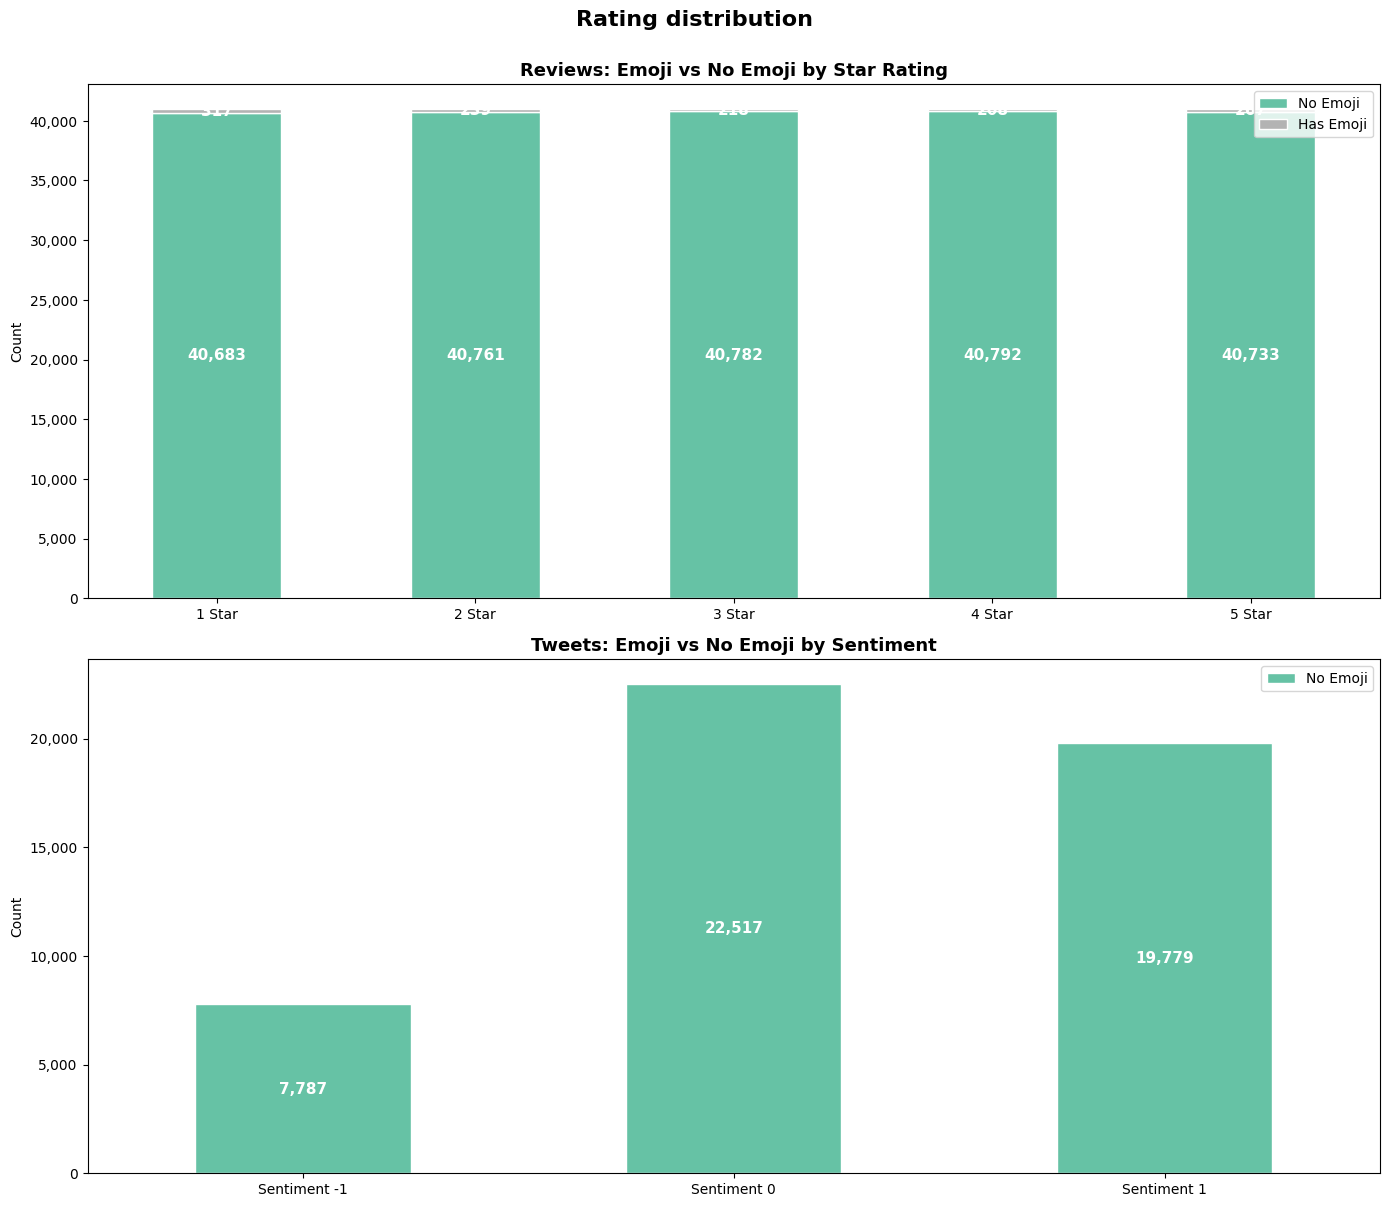

In [154]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 12))  
fig.suptitle("Rating distribution", fontsize=16, fontweight="bold", y=1.002)
plt.subplots_adjust(hspace=0.45)


# 1. Stacked bar — emoji x star rating
plot_stacked_bars(star_emoji, "Reviews: Emoji vs No Emoji by Star Rating", ax=axs[0])
axs[0].set_ylabel("Count")

# 2. Stacked bar — emoji x sentiment
plot_stacked_bars(sent_emoji, "Tweets: Emoji vs No Emoji by Sentiment", ax=axs[1])
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Review ratings was equal while tweets sentiment are not.

### Text length distribution (separate by reviews and tweets, by ratings)

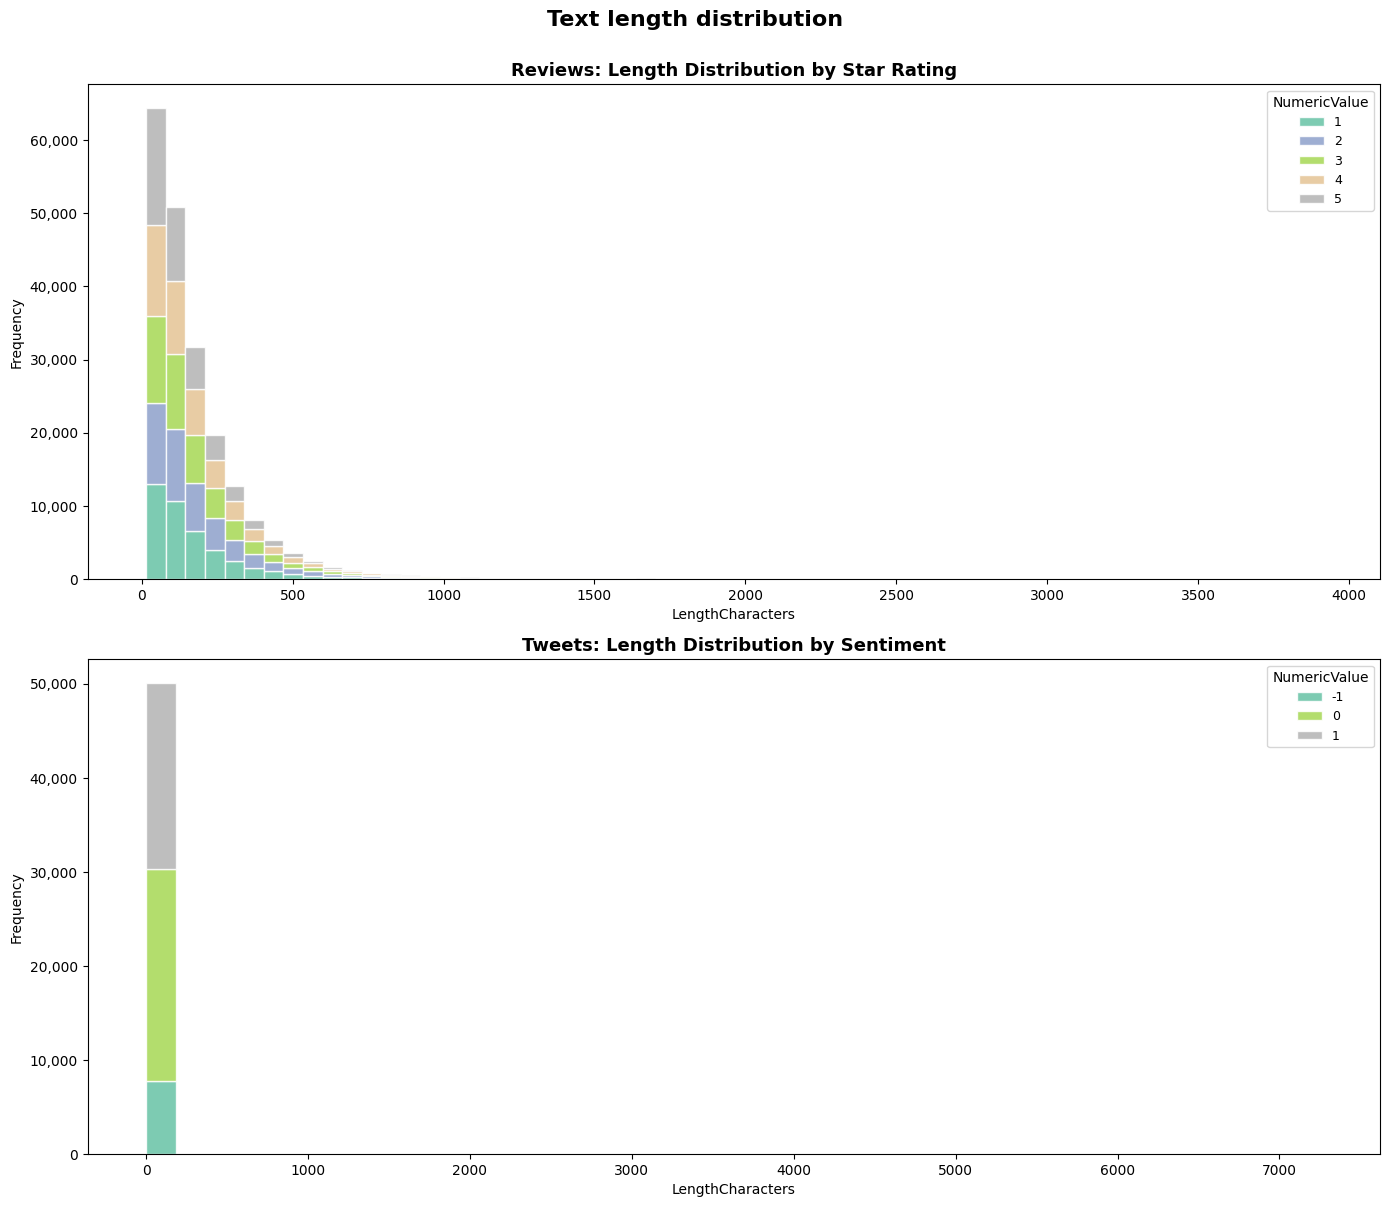

In [155]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 12))  
fig.suptitle("Text length distribution", fontsize=16, fontweight="bold", y=1.002)
plt.subplots_adjust(hspace=0.45)

# 3. Stacked distribution — review length by star rating
plot_stacked_distribution(
    reviews, "LengthCharacters", "NumericValue", star_labels,
    "Reviews: Length Distribution by Star Rating", ax=axs[0], bins_=60
)

# 4. Stacked distribution — tweet length by sentiment
plot_stacked_distribution(
    tweets, "LengthCharacters", "NumericValue", sent_labels,
    "Tweets: Length Distribution by Sentiment", ax=axs[1], bins_=40
)

plt.tight_layout()
plt.show()

Clearly, the text length data was highly positive skewed and the value in the higher end are most likely be outliers. A boxplot is a standardized way of displaying the data based on their quantiles. 

### Text length boxplots (separate by reviews and tweets)

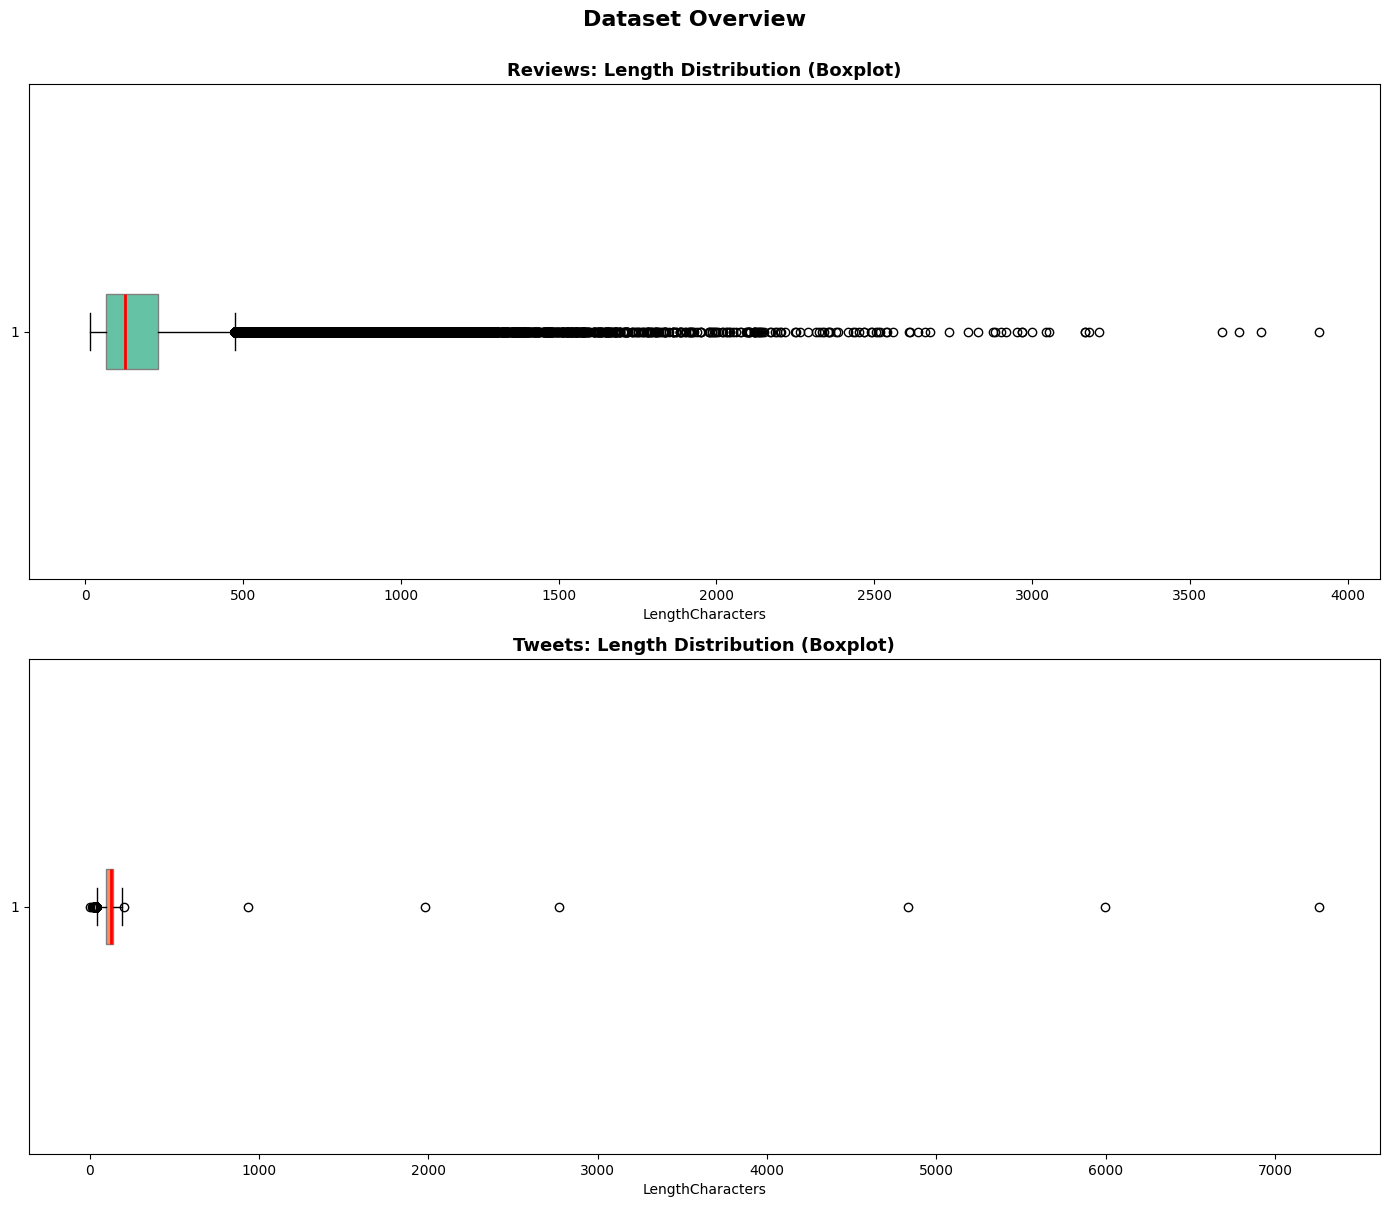

In [156]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 12))  
fig.suptitle("Dataset Overview", fontsize=16, fontweight="bold", y=1.002)
plt.subplots_adjust(hspace=0.45)

# 5. Boxplot — review length
axs[0].boxplot(reviews["LengthCharacters"].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor="#66c2a5", color="grey"),
               medianprops=dict(color="red", linewidth=2))
axs[0].set_title("Reviews: Length Distribution (Boxplot)", fontweight="bold", fontsize=13)
axs[0].set_xlabel("LengthCharacters")
axs[0].ticklabel_format(style="plain", axis="x")

# 6. Boxplot — tweet length
axs[1].boxplot(tweets["LengthCharacters"].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor="#fc8d62", color="grey"),
               medianprops=dict(color="red", linewidth=2))
axs[1].set_title("Tweets: Length Distribution (Boxplot)", fontweight="bold", fontsize=13)
axs[1].set_xlabel("LengthCharacters")
axs[1].ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

The text length data is cleary skewed, we will need to deal with skewness and outliers on the next stage.

### Text length vs Rating proportion (separate by reviews and tweets)

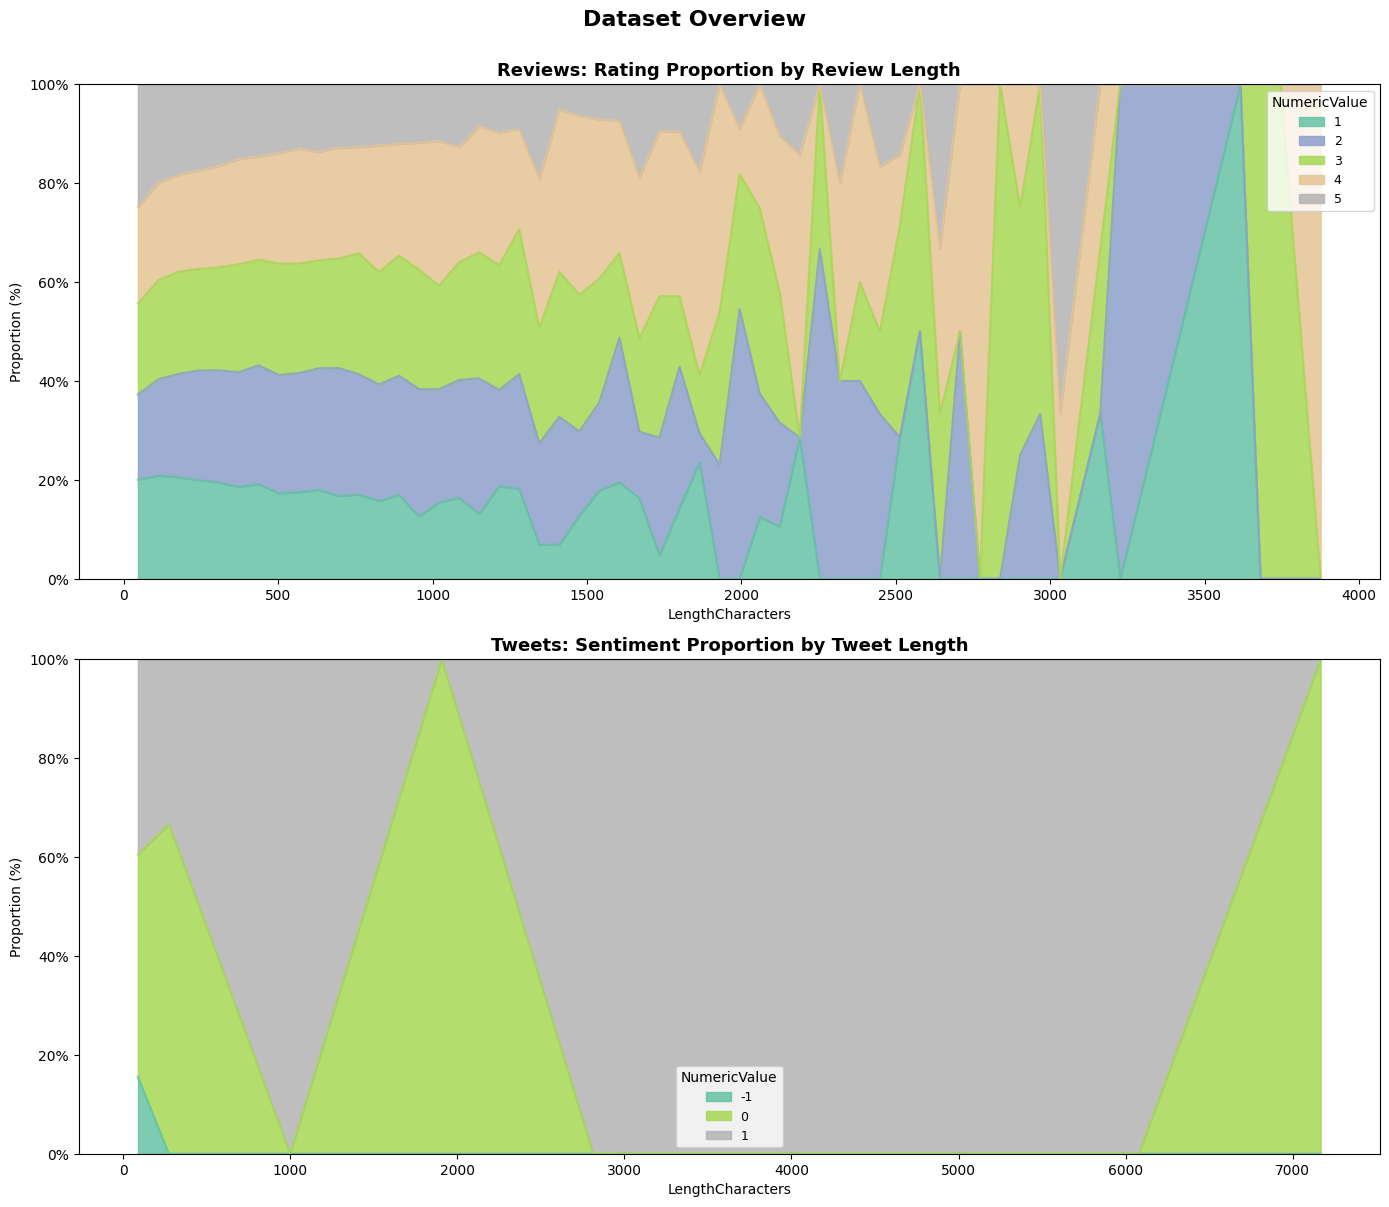

In [157]:
fig, axs = plt.subplots(nrows=2, figsize=(14, 12))  
fig.suptitle("Dataset Overview", fontsize=16, fontweight="bold", y=1.002)
plt.subplots_adjust(hspace=0.45)

# 7. Percentage area — review length by star rating
plot_percentage_area(
    reviews, "LengthCharacters", "NumericValue", star_labels,
    "Reviews: Rating Proportion by Review Length", ax=axs[0], bins_=60
)

# 8. Percentage area — tweet length by sentiment
plot_percentage_area(
    tweets, "LengthCharacters", "NumericValue", sent_labels,
    "Tweets: Sentiment Proportion by Tweet Length", ax=axs[1], bins_=40
)

plt.tight_layout()
plt.show()

As visualised, ratings proportion in the text length data are mostly stable when the length are in IQR range, and are mostly unstable out of that range. 

### Top words per ratings (separate by reviews and tweets)

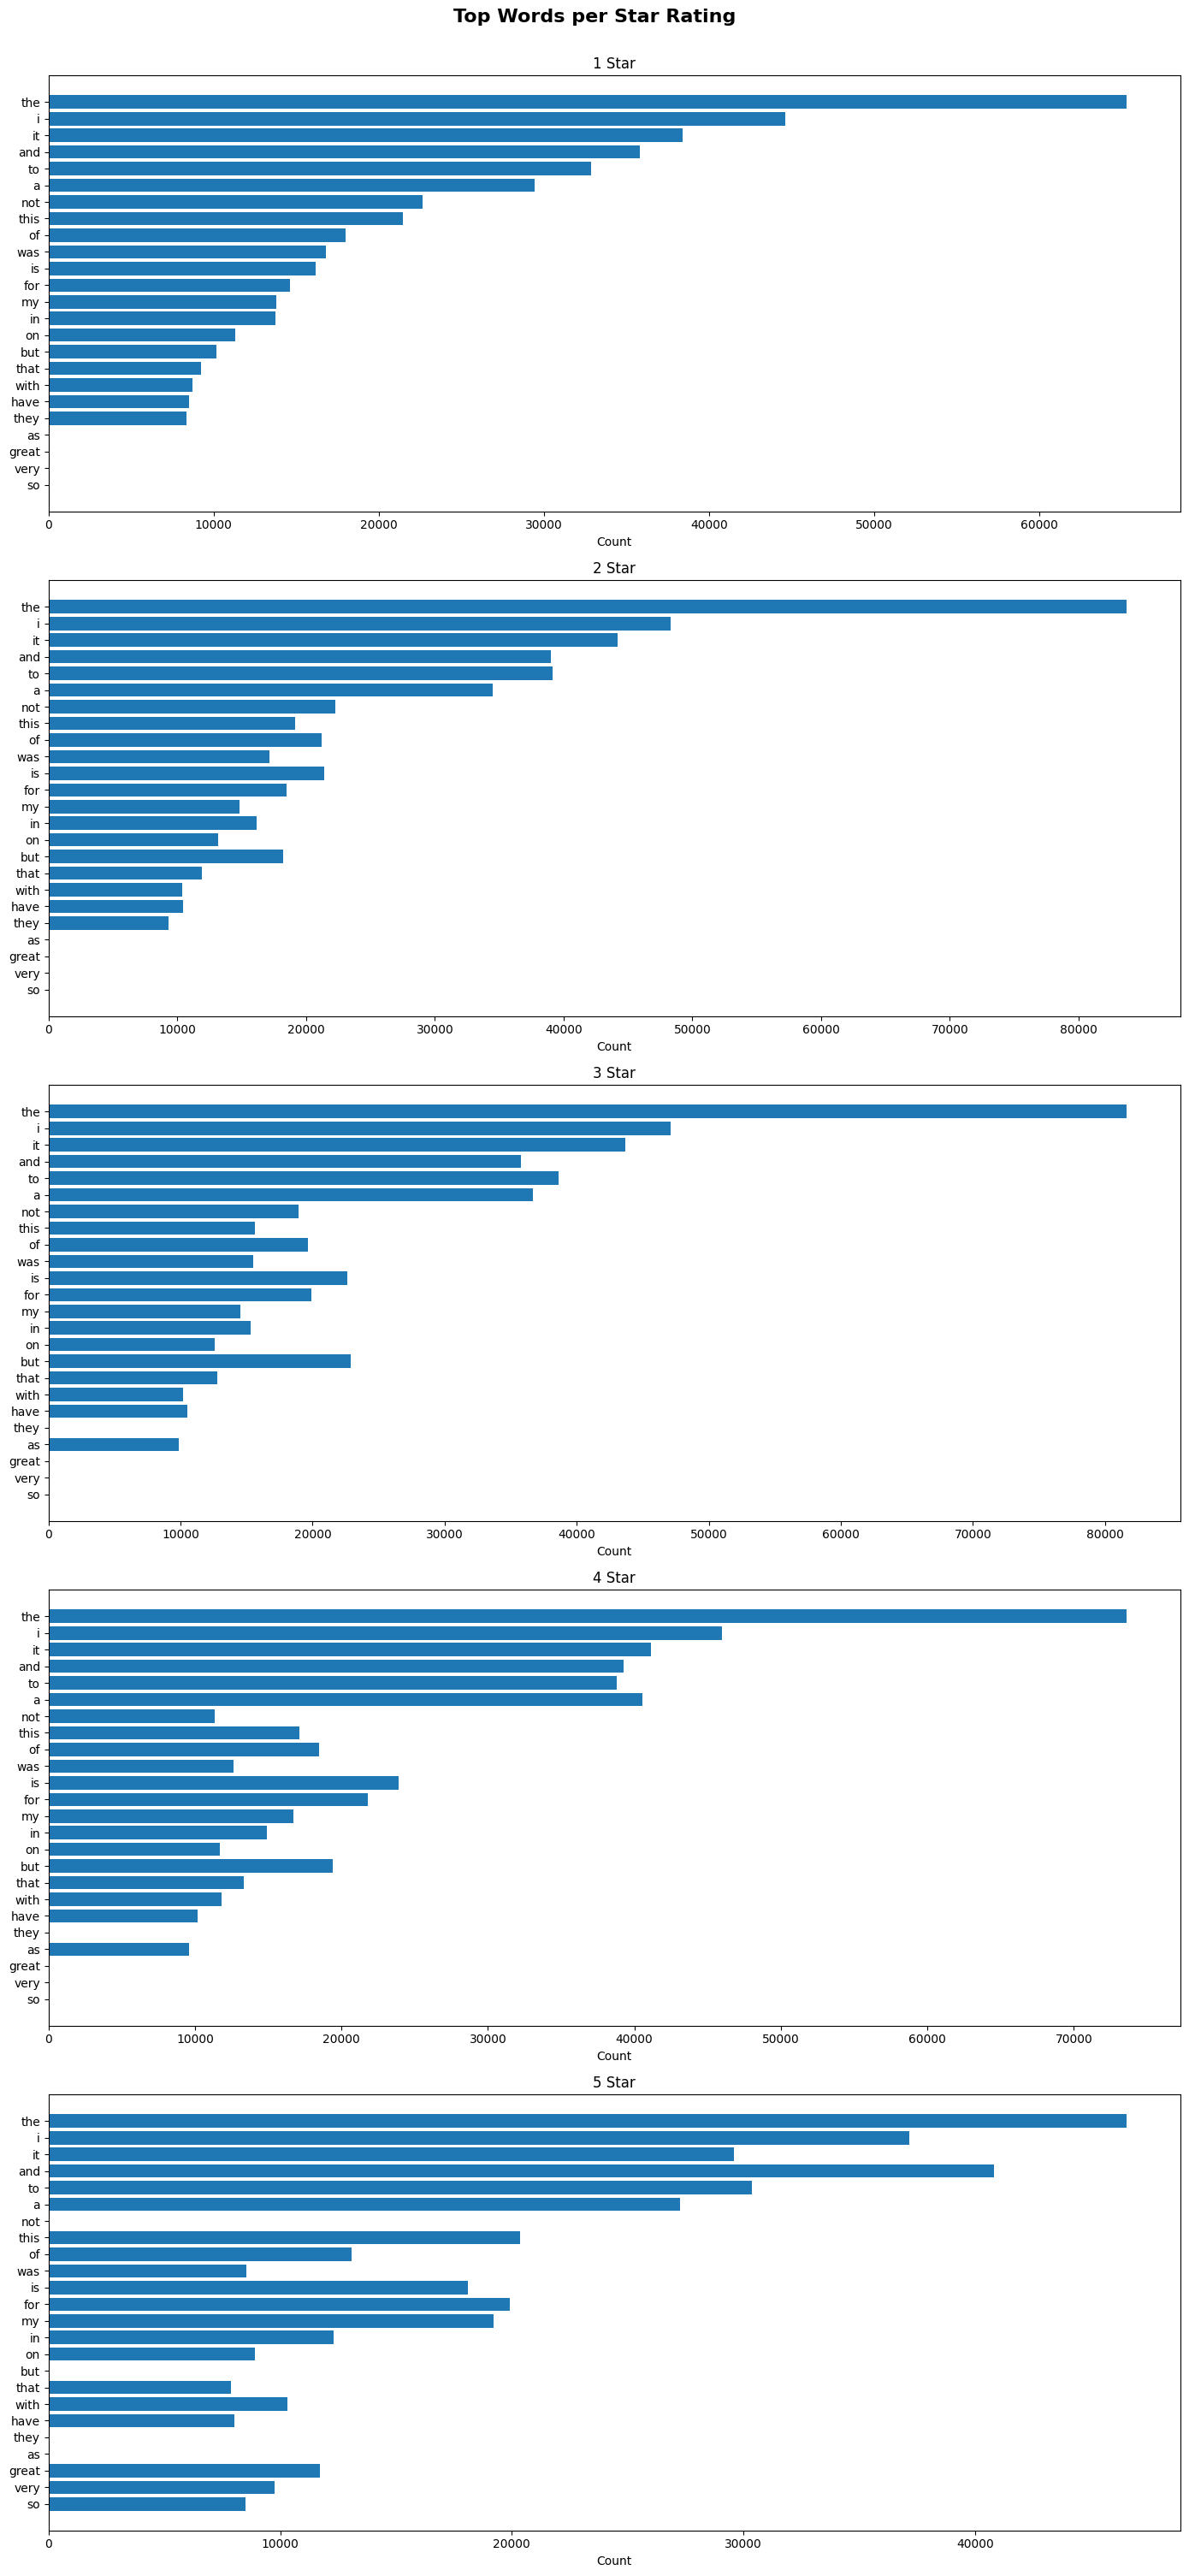

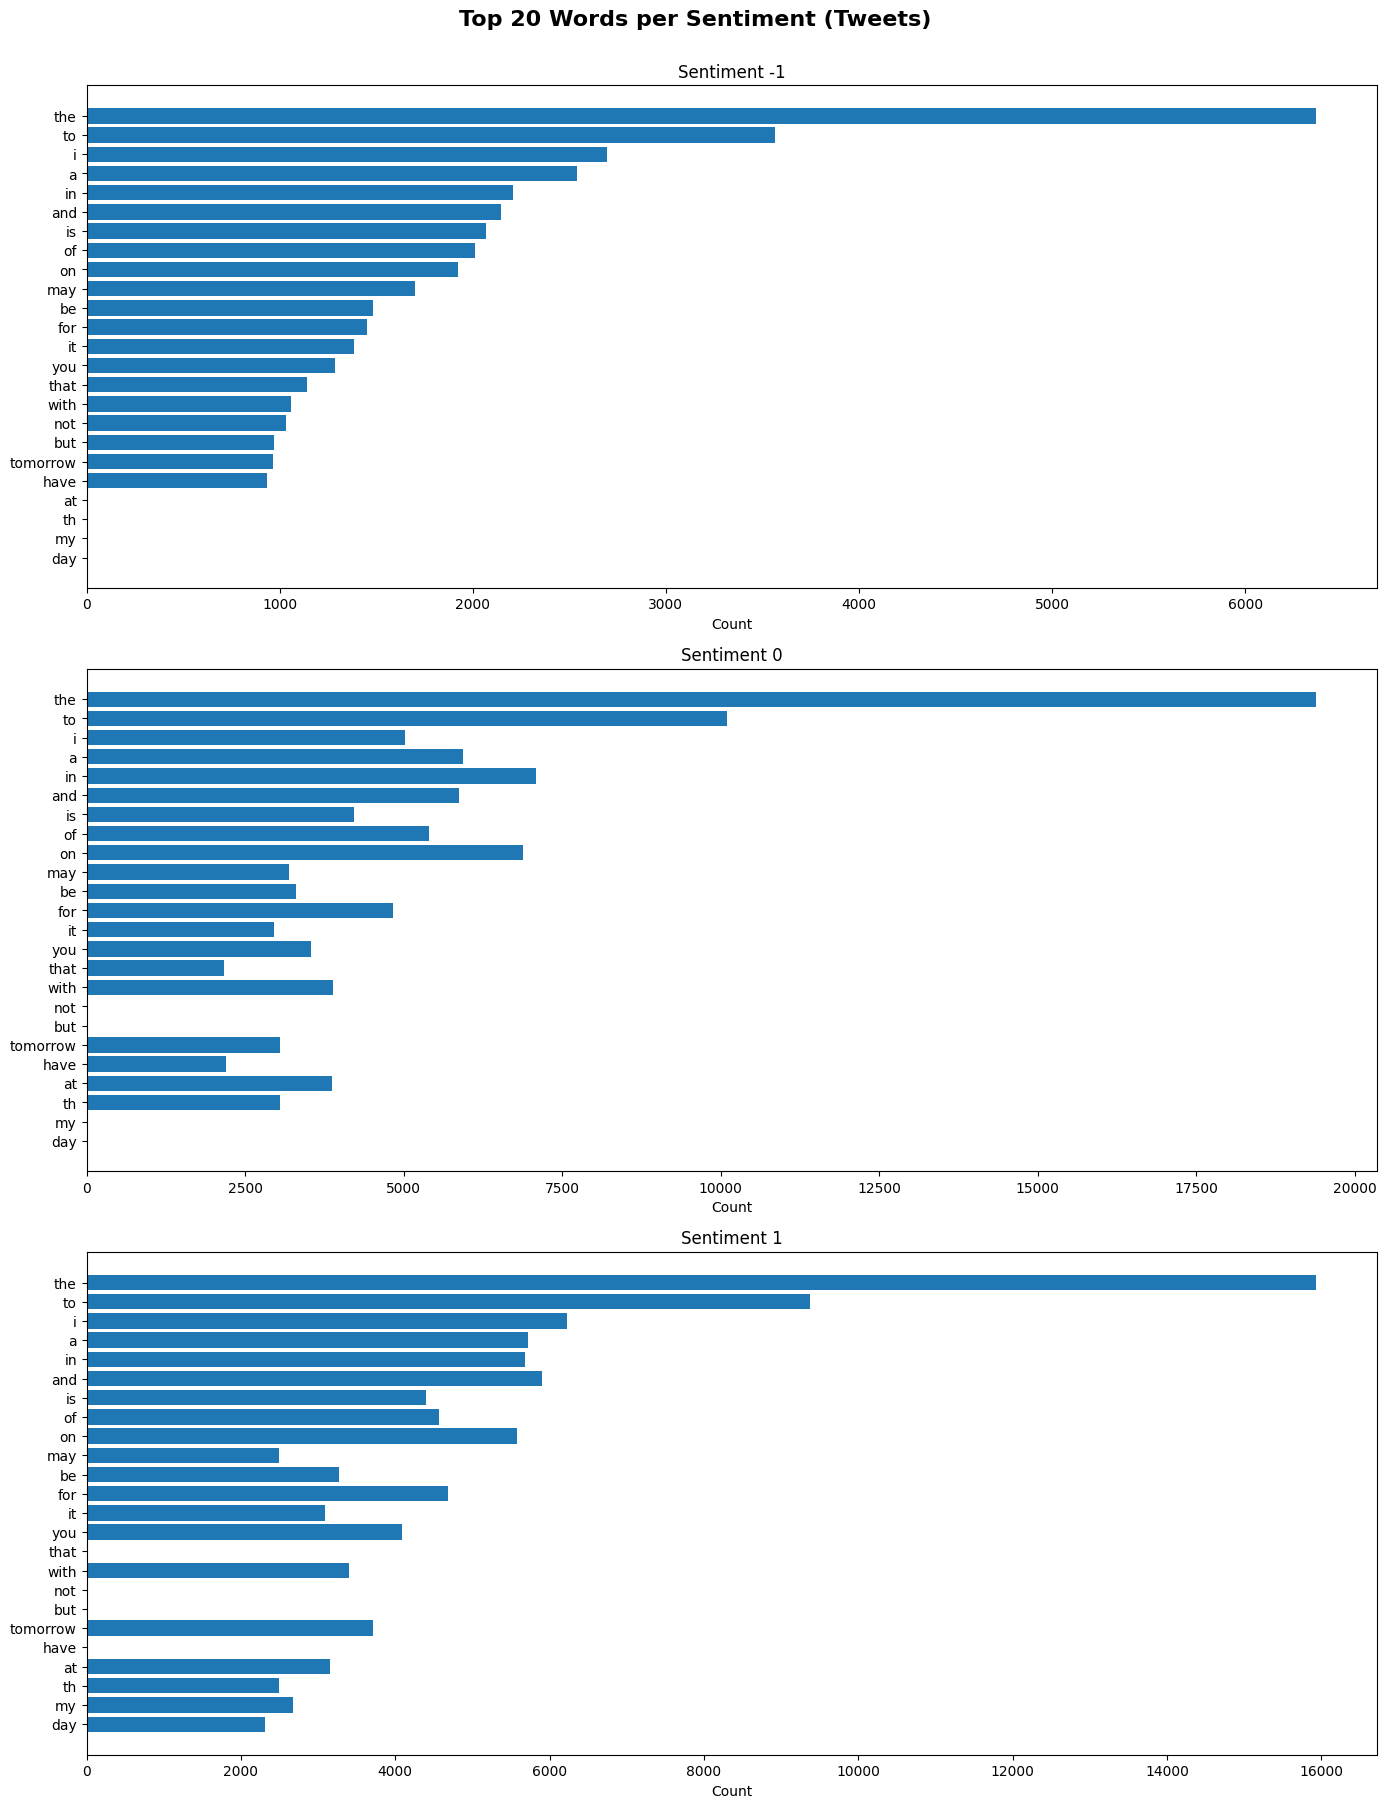

In [158]:
# Help function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)       # keep only letters
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

def get_top_words(df, label_col, text_col, label_value, n=20):
    text = " ".join(df[df[label_col] == label_value][text_col])
    words = text.split()
    counter = Counter(words)
    return pd.DataFrame(counter.most_common(n), columns=["Word", "Count"])

# Plots for Reviews
reviews["CleanText"] = reviews["Text"].astype(str).apply(clean_text)

fig, axes = plt.subplots(nrows=5, figsize=(14,30), sharey=True)
fig.suptitle("Top Words per Star Rating", fontsize=16, fontweight="bold", y=1.002)
plt.subplots_adjust(hspace=0.45)

for i, label in enumerate(star_labels):
    top_words = get_top_words(reviews, "NumericValue", "CleanText", label)
    axes[i].barh(top_words["Word"], top_words["Count"])
    axes[i].invert_yaxis()
    axes[i].set_title(f"{int(label)} Star")
    axes[i].set_xlabel("Count")

plt.tight_layout()
plt.show()


# Plots for Tweets
tweets["CleanText"] = tweets["Text"].astype(str).apply(clean_text)

fig, axes = plt.subplots(nrows=3, figsize=(14,18), sharey=True)
fig.suptitle("Top 20 Words per Sentiment (Tweets)", fontsize=16, fontweight="bold", y=1.002)
plt.subplots_adjust(hspace=0.45)

for i, label in enumerate(sent_labels):
    top_words = get_top_words(tweets, "NumericValue", "CleanText", label)

    axes[i].barh(top_words["Word"], top_words["Count"])
    axes[i].invert_yaxis()
    axes[i].set_title(f"Sentiment {int(label)}")
    axes[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

The top 20 words actually say nothing about the ratings as most of them are function words and are neutral. Thus in order to make good ratings prediction, we need to deal with those words in the next stage.

## 3/ Label Mapping

Map raw star ratings (1–5) to sentiment classes (−1, 0, +1). Tweets already use (−1, 0, +1) and are passed through unchanged.

In [159]:
def stars_to_sentiment(stars: int) -> int:
    if stars <= 2:
        return -1
    if stars == 3:
        return 0
    return 1

df = df.copy()
is_review = df["Type"] == "Review"
df["sentiment"] = np.where(
    is_review,
    df["NumericValue"].apply(stars_to_sentiment),   # reviews: map stars
    df["NumericValue"]                                # tweets: already -1/0/1
)
df["sentiment"] = df["sentiment"].astype(int)

print(df["sentiment"].value_counts().sort_index())
print(pd.crosstab(df["Type"], df["sentiment"]))

sentiment
-1     89787
 0     63517
 1    101779
Name: count, dtype: int64
sentiment     -1      0      1
Type                          
Review     82000  41000  82000
Tweet       7787  22517  19779


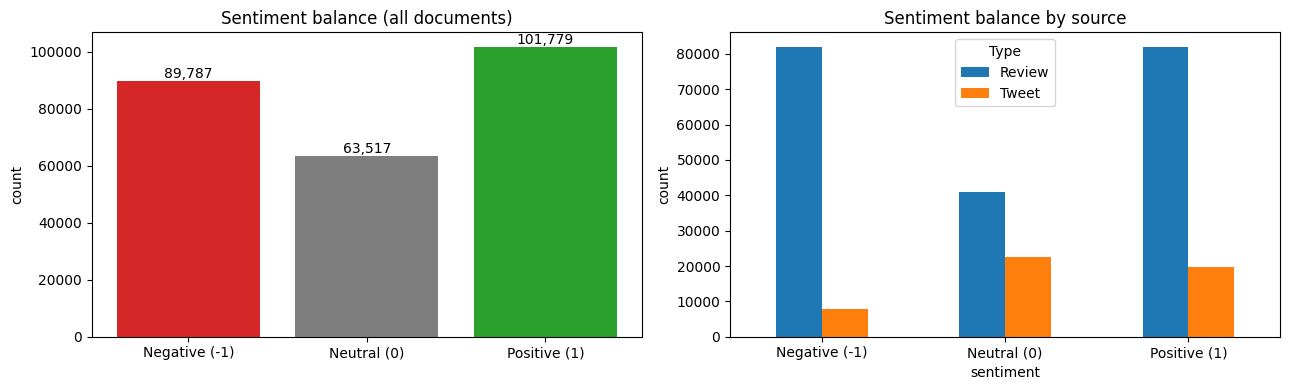

Class proportions:
sentiment
-1    0.352
 0    0.249
 1    0.399
Imbalance ratio (max/min): 1.60


In [160]:
# Final 3-class label balance — this is what the model predicts.
# Motivates stratified splitting and macro-F1 as the evaluation metric.
order = [-1, 0, 1]
names = ["Negative (-1)", "Neutral (0)", "Positive (1)"]
cols  = ["#d62728", "#7f7f7f", "#2ca02c"]

fig, axs = plt.subplots(1, 2, figsize=(13, 4))

counts = df["sentiment"].value_counts().reindex(order)
axs[0].bar(names, counts.values, color=cols)
axs[0].set_title("Sentiment balance (all documents)")
axs[0].set_ylabel("count")
for i, v in enumerate(counts.values):
    axs[0].text(i, v, f"{v:,}", ha="center", va="bottom")

pd.crosstab(df["sentiment"], df["Type"]).reindex(order).plot(
    kind="bar", ax=axs[1], color=["#1f77b4", "#ff7f0e"])
axs[1].set_title("Sentiment balance by source")
axs[1].set_xticklabels(names, rotation=0)
axs[1].set_ylabel("count")
plt.tight_layout(); plt.show()

p = counts / counts.sum()
print("Class proportions:"); print(p.round(3).to_string())
print(f"Imbalance ratio (max/min): {counts.max()/counts.min():.2f}")

## 4/ EDA Cleaning (shared across all routes)

Light noise removal only. Removes HTML, URLs, @mentions and the `#` symbol, then lowercases. **Does not** strip punctuation, numbers, or emojis, as those decisions belong to each route's own preprocessing pipeline.

In [161]:
_url_re  = re.compile(r"http\S+|www\.\S+")
_ment_re = re.compile(r"@\w+")
_html_re = re.compile(r"<[^>]+>")
_sp_re   = re.compile(r"\s+")

def clean_eda(text: str) -> str:
    """Light EDA cleaning shared by all routes."""
    text = str(text)
    text = html.unescape(text)          # &amp; -> &, &#39; -> '
    text = _html_re.sub(" ", text)      # strip <br>, <p>, etc.
    text = _url_re.sub(" ", text)       # remove links
    text = _ment_re.sub(" ", text)      # remove @handles
    text = text.replace("#", " ")       # keep hashtag word, drop #
    text = text.lower()
    text = _sp_re.sub(" ", text).strip()
    return text

df["clean_eda"] = df["Text"].map(clean_eda)
print(f"Rows              : {len(df):,}")
print(f"Empty after clean : {(df['clean_eda'].str.len() == 0).sum():,}")
print(f"Exact duplicates  : {df['clean_eda'].duplicated().sum():,}")

# Sanity check: before/after pairs
for typ in ["Review", "Tweet"]:
    print(f"\n--- {typ} ---")
    sample = df[df["Type"] == typ].head(3)
    for raw, clean in zip(sample["Text"], sample["clean_eda"]):
        print(f"  RAW  : {raw[:110]}")
        print(f"  CLEAN: {clean[:110]}\n")

Rows              : 255,083
Empty after clean : 0
Exact duplicates  : 1,527

--- Review ---
  RAW  : Arrived broken. Manufacturer defect. Two of the legs of the base were not completely formed, so there was no w
  CLEAN: arrived broken. manufacturer defect. two of the legs of the base were not completely formed, so there was no w

  RAW  : the cabinet dot were all detached from backing... got me
  CLEAN: the cabinet dot were all detached from backing... got me

  RAW  : I received my first order of this product and it was broke so I ordered it again. The second one was broke in 
  CLEAN: i received my first order of this product and it was broke so i ordered it again. the second one was broke in 


--- Tweet ---
  RAW  : Won the match #getin . Plus\u002c tomorrow is a very busy day\u002c with Awareness Day\u2019s and debates. Gul
  CLEAN: won the match getin . plus\u002c tomorrow is a very busy day\u002c with awareness day\u2019s and debates. gulp

  RAW  : Some areas of New England co

## 5/ Corpus Statistics (shared across all routes)

Computed on `df["tokens_eda"]` — simple letter-sequence tokens from `clean_eda`. No stopword removal, no lemmatization. This gives an unbiased picture of the raw corpus before any modeling decisions.

In [162]:
# Compute df["tokens_eda"]

def tokenize_eda(text: str, min_len: int = 2) -> list:
    return [t for t in re.findall(r"[a-z]+", text) if len(t) >= min_len]

df["tokens_eda"] = df["clean_eda"].map(tokenize_eda)
print(f"Sample tokens: {df['tokens_eda'].iloc[0][:10]}")

Sample tokens: ['arrived', 'broken', 'manufacturer', 'defect', 'two', 'of', 'the', 'legs', 'of', 'the']


#### Total token and total vocabulary

In [163]:
from collections import Counter

all_tokens_eda = [t for toks in df["tokens_eda"] for t in toks]
vocab_eda      = Counter(all_tokens_eda)

print(f"Total tokens     : {len(all_tokens_eda):,}")
print(f"Vocabulary size  : {len(vocab_eda):,}")
print(f"Type-token ratio : {len(vocab_eda)/len(all_tokens_eda):.4f}")
print(f"Top 10 words     : {vocab_eda.most_common(10)}")

Total tokens     : 7,421,572
Vocabulary size  : 64,962
Type-token ratio : 0.0088
Top 10 words     : [('the', 393236), ('it', 234964), ('and', 205307), ('to', 203090), ('is', 112937), ('for', 105812), ('of', 102456), ('this', 98701), ('in', 87903), ('my', 84407)]


#### Zipf's law analysis

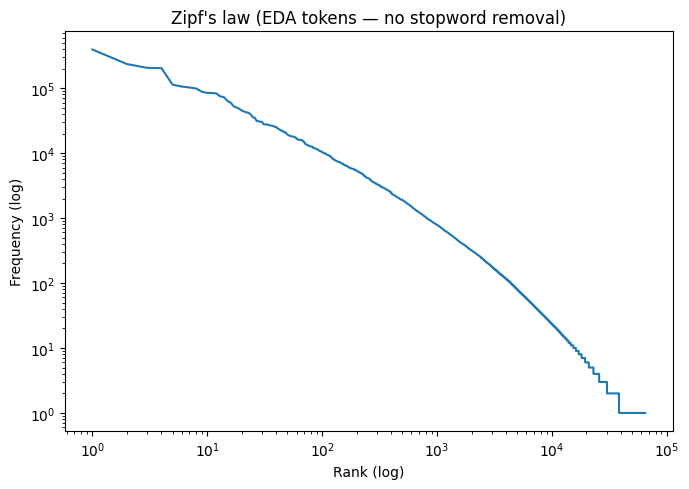

Words appearing only once : 26,591


In [164]:
freqs = np.array(sorted(vocab_eda.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, freqs)
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.title("Zipf's law (EDA tokens — no stopword removal)")
plt.tight_layout()
plt.show()

print(f"Words appearing only once : {sum(1 for v in vocab_eda.values() if v == 1):,}")

#### Top 20 words per sentiment (EDA tokens)

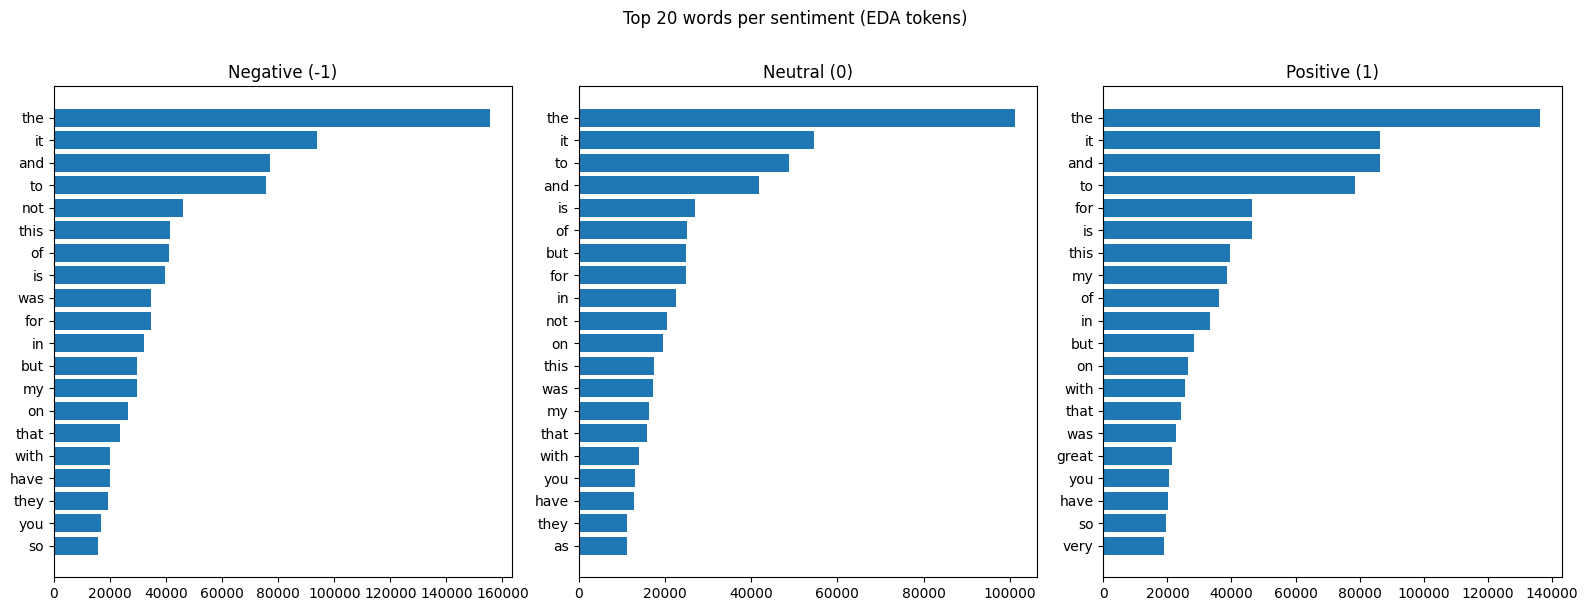

In [165]:
def top_words_for(label, k=20):
    toks = [t for toks in df.loc[df["sentiment"] == label, "tokens_eda"] for t in toks]
    return Counter(toks).most_common(k)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, lbl, name in zip(axes, [-1, 0, 1], ["Negative", "Neutral", "Positive"]):
    words, counts = zip(*top_words_for(lbl))
    ax.barh(words, counts); ax.invert_yaxis()
    ax.set_title(f"{name} ({lbl})")

plt.suptitle("Top 20 words per sentiment (EDA tokens)", y=1.01)
plt.tight_layout()
plt.show()

#### Bigram frequencies

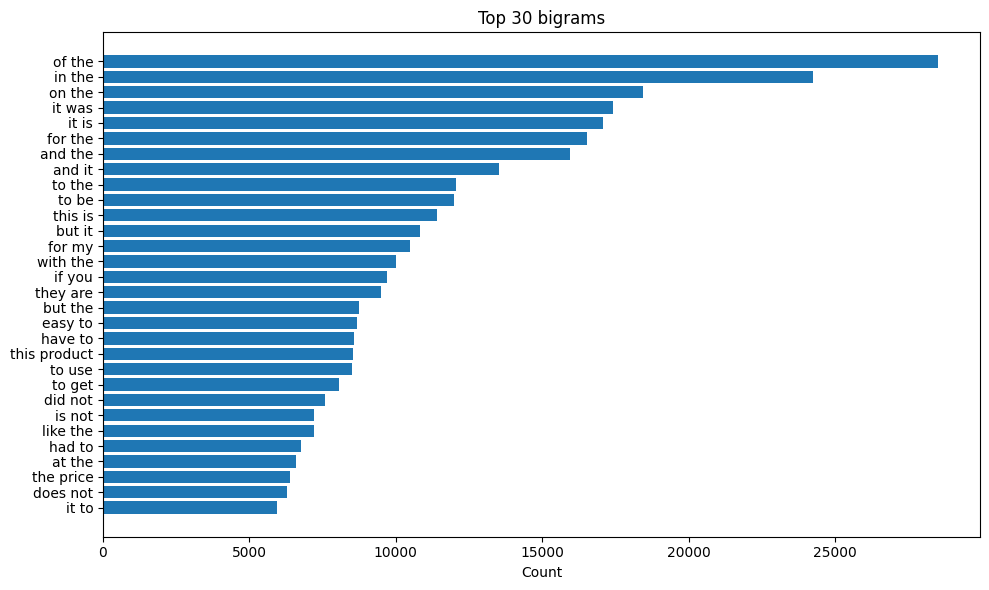

In [166]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_cv    = CountVectorizer(ngram_range=(2, 2), min_df=10)
Xb           = bigram_cv.fit_transform(df["clean_eda"])
sums_b       = np.asarray(Xb.sum(axis=0)).ravel()
bg_terms     = np.array(bigram_cv.get_feature_names_out())
top30_idx    = np.argsort(sums_b)[::-1][:30]
top_bg       = bg_terms[top30_idx]
top_bg_cnt   = sums_b[top30_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_bg[::-1], top_bg_cnt[::-1])
plt.title("Top 30 bigrams"); plt.xlabel("Count")
plt.tight_layout()
plt.show()

#### Word clouds per sentiment

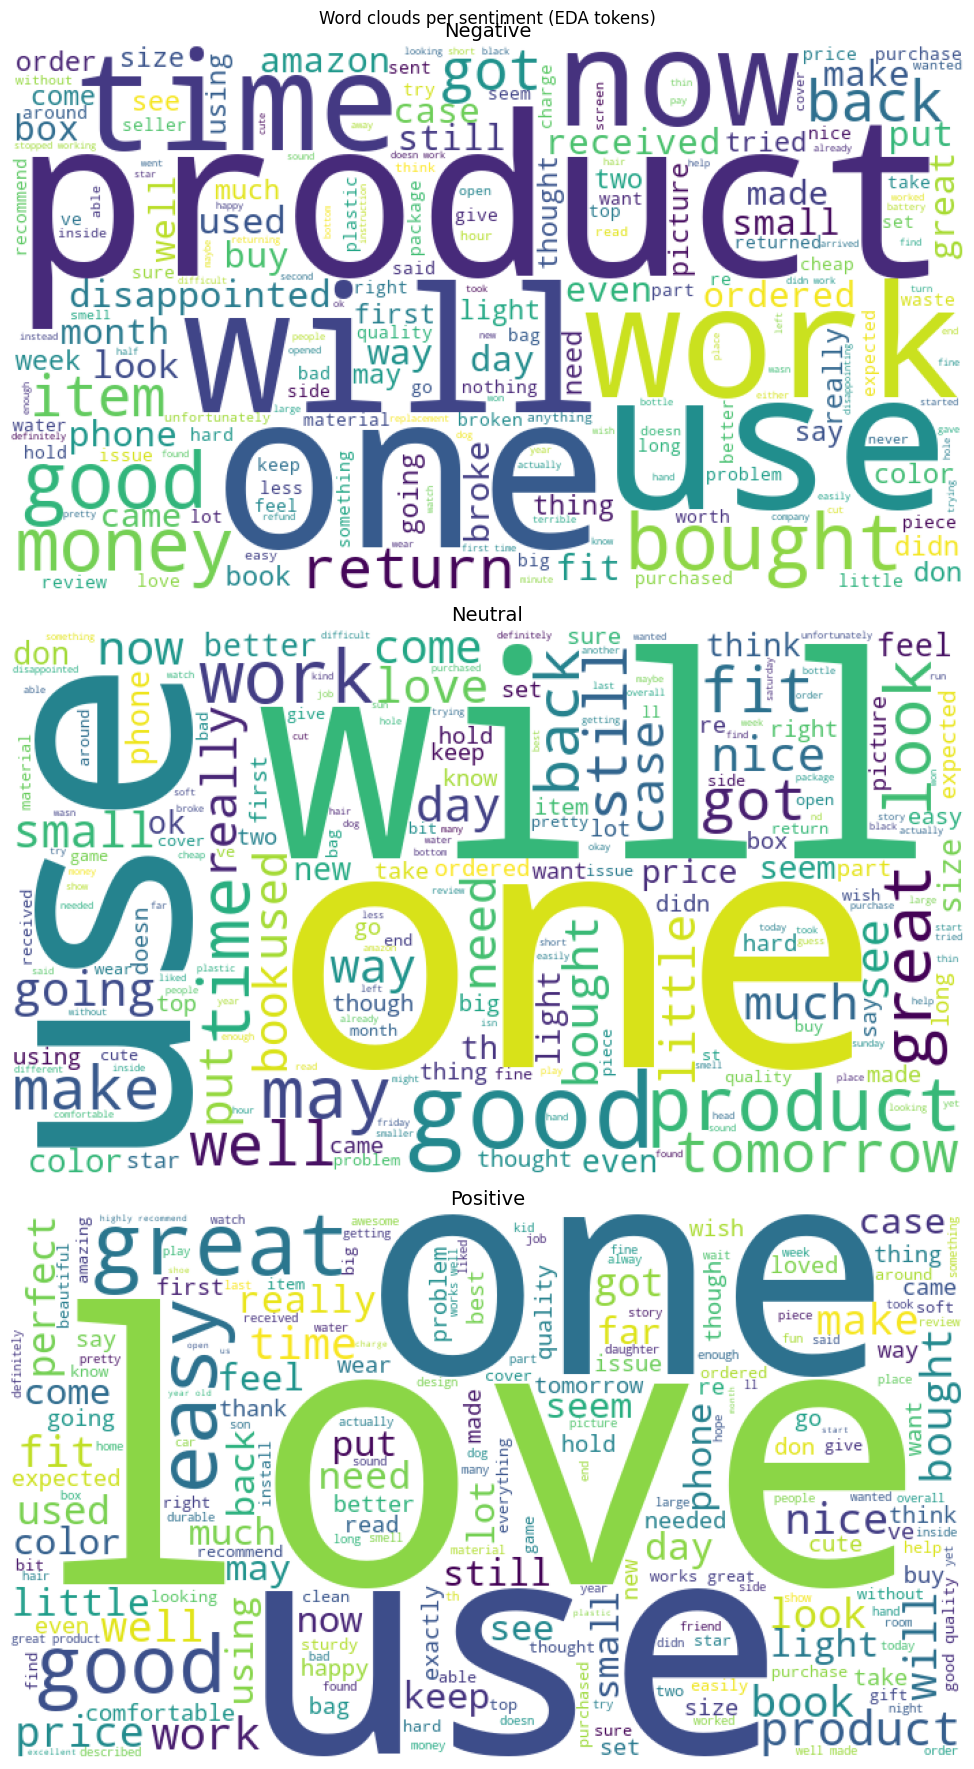

In [167]:
from wordcloud import WordCloud

fig, axes = plt.subplots(nrows=3, figsize=(14, 18))
for ax, lbl, name in zip(axes, [-1, 0, 1], ["Negative", "Neutral", "Positive"]):
    text = " ".join(
        t for toks in df.loc[df["sentiment"] == lbl, "tokens_eda"] for t in toks)
    wc = WordCloud(width=700, height=400, background_color="white").generate(text)
    ax.imshow(wc); ax.axis("off"); ax.set_title(name, fontsize=14)

plt.suptitle("Word clouds per sentiment (EDA tokens)")
plt.tight_layout()
plt.show()

#### Intermittency

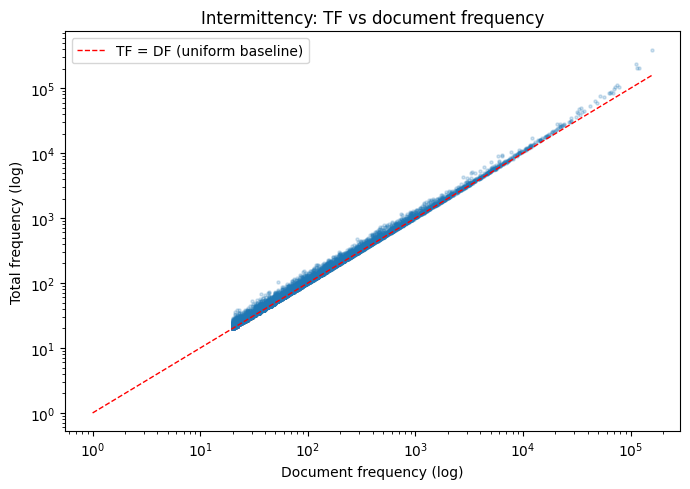

Most bursty words (high avg occurrences per document they appear in):
  the                   tf=393,219  df=157,937  burst=2.5x
  it                    tf=234,962  df=112,069  burst=2.1x
  digi                  tf=    104  df=    53  burst=2.0x
  blah                  tf=     67  df=    37  burst=1.8x
  to                    tf=203,089  df=113,317  burst=1.8x
  sights                tf=     52  df=    30  burst=1.7x
  wiper                 tf=     38  df=    22  burst=1.7x
  and                   tf=205,301  df=119,697  burst=1.7x
  bassinet              tf=     36  df=    21  burst=1.7x
  neutral               tf=    152  df=    92  burst=1.7x


In [168]:
# Intermittency: words appear in bursts across documents, not uniformly.
# We show this as total_freq vs document_freq on a log-log plot.
# Words far above the diagonal appear many times per document they're in (bursty).
from sklearn.feature_extraction.text import CountVectorizer

_cv_int    = CountVectorizer(min_df=20)
_X_int     = _cv_int.fit_transform(df["clean_eda"])
_terms_int = _cv_int.get_feature_names_out()
_tf_int    = np.asarray(_X_int.sum(axis=0)).ravel()
_df_int    = np.asarray((_X_int > 0).sum(axis=0)).ravel()
_burst     = _tf_int / _df_int  # avg occurrences per doc the word appears in

plt.figure(figsize=(7, 5))
plt.scatter(_df_int, _tf_int, alpha=0.2, s=5)
_diag = np.linspace(1, _df_int.max(), 100)
plt.plot(_diag, _diag, "r--", linewidth=1, label="TF = DF (uniform baseline)")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Document frequency (log)")
plt.ylabel("Total frequency (log)")
plt.title("Intermittency: TF vs document frequency")
plt.legend(); plt.tight_layout(); plt.show()

print("Most bursty words (high avg occurrences per document they appear in):")
for idx in np.argsort(_burst)[::-1][:10]:
    print(f"  {_terms_int[idx]:20s}  tf={_tf_int[idx]:>7,}  "
          f"df={_df_int[idx]:>6,}  burst={_burst[idx]:.1f}x")

#### Word co-occurrence

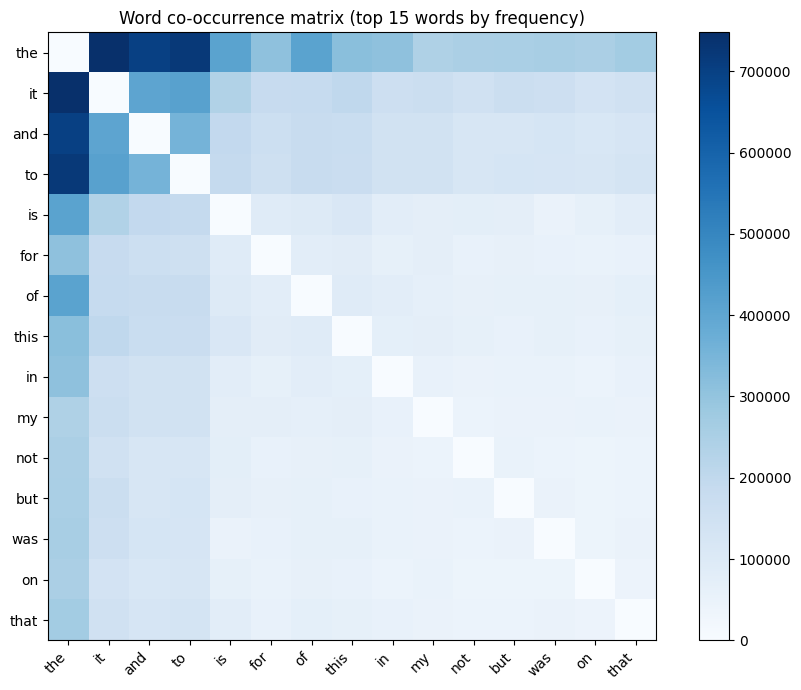

In [169]:
# Word co-occurrence: which top words tend to appear in the same documents?
from sklearn.feature_extraction.text import CountVectorizer

_top15 = [w for w, _ in vocab_eda.most_common(15)]
_cv_co = CountVectorizer(vocabulary=_top15)
_X_co  = _cv_co.fit_transform(df["clean_eda"])
_cooc  = (_X_co.T @ _X_co).toarray().astype(float)
np.fill_diagonal(_cooc, 0)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(_cooc, cmap="Blues")
ax.set_xticks(range(len(_top15))); ax.set_xticklabels(_top15, rotation=45, ha="right")
ax.set_yticks(range(len(_top15))); ax.set_yticklabels(_top15)
plt.colorbar(im, ax=ax)
ax.set_title("Word co-occurrence matrix (top 15 words by frequency)")
plt.tight_layout()
plt.show()

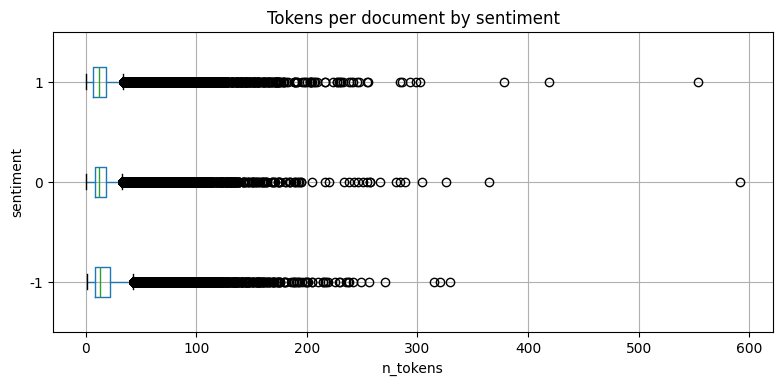

              count       mean        std  min  25%   50%   75%    max
sentiment                                                             
-1          89787.0  17.658926  16.236593  1.0  8.0  13.0  22.0  329.0
 0          63517.0  16.182471  15.290918  0.0  8.0  12.0  18.0  592.0
 1         101779.0  15.948820  15.534567  0.0  7.0  12.0  18.0  554.0


In [60]:
df.boxplot(column="n_tokens", by="sentiment", vert=False, figsize=(9, 4))
plt.suptitle(""); plt.title("Tokens per document by sentiment"); plt.xlabel("n_tokens")
plt.show()
print(df.groupby("sentiment")["n_tokens"].describe())

In [ ]:
cum = np.cumsum(freqs) / freqs.sum()
plt.figure(figsize=(7, 5))
plt.plot(ranks, cum)
plt.axhline(0.9, ls="--", color="grey")
plt.xlabel("Number of top words kept")
plt.ylabel("Cumulative token coverage")
plt.title("Vocabulary coverage")
plt.show()
# e.g. "the top N words cover 90% of all tokens" -> a defensible max_features.

## 6/ Train / Validation / Test Split
 
Split done **once** on `clean_eda` so every encoder route (A/B/C) and every
classifier trains and is evaluated on the *identical* partition — a prerequisite
for fair model comparison.
 
- **70 / 15 / 15** train / validation / test.
- **Stratified on `sentiment × Type` jointly.** Reviews and Tweets have very
  different sentiment profiles, so joint stratification keeps all three splits
  balanced on both label *and* domain, enabling per-domain F1 later.
- A `split` column is written back onto `df`; standalone copies are also saved
  so downstream notebooks can load the exact same partition.

In [170]:
from sklearn.model_selection import train_test_split
 
SEED = 42
 
# Joint key: every (sentiment, Type) combination is its own stratum.
strat_key = df["sentiment"].astype(str) + "_" + df["Type"].astype(str)
 
idx = df.index.to_numpy()
 
# First carve off TEST (15%), keeping 85% as a temporary pool.
idx_train_val, idx_test = train_test_split(
    idx,
    test_size=0.15,
    stratify=strat_key,
    random_state=SEED,
)
 
# From the 85% pool, carve VALIDATION. 0.15 / 0.85 = 0.1765 -> 15% of the whole.
idx_train, idx_val = train_test_split(
    idx_train_val,
    test_size=0.15 / 0.85,
    stratify=strat_key.loc[idx_train_val],
    random_state=SEED,
)
 
# Write the assignment back onto df as a single column.
df["split"] = "train"
df.loc[idx_val,  "split"] = "val"
df.loc[idx_test, "split"] = "test"
 
print("Split sizes:")
print(df["split"].value_counts())
print(f"\nFractions: {(df['split'].value_counts(normalize=True)).round(3).to_dict()}")
 

Split sizes:
split
train    178557
val       38263
test      38263
Name: count, dtype: int64

Fractions: {'train': 0.7, 'val': 0.15, 'test': 0.15}


In [171]:
print("Sentiment proportions within each split (should match across splits):")
print(pd.crosstab(df["split"], df["sentiment"], normalize="index").round(3))
 
print("\nType proportions within each split:")
print(pd.crosstab(df["split"], df["Type"], normalize="index").round(3))
 
print("\nJoint sentiment×Type proportions per split (sanity — columns near-identical):")
joint = (
    df.assign(key=strat_key)
      .pipe(lambda d: pd.crosstab(d["key"], d["split"], normalize="columns"))
      .round(3)
)
print(joint)

Sentiment proportions within each split (should match across splits):
sentiment     -1      0      1
split                         
test       0.352  0.249  0.399
train      0.352  0.249  0.399
val        0.352  0.249  0.399

Type proportions within each split:
Type   Review  Tweet
split               
test    0.804  0.196
train   0.804  0.196
val     0.804  0.196

Joint sentiment×Type proportions per split (sanity — columns near-identical):
split       test  train    val
key                           
-1_Review  0.321  0.321  0.321
-1_Tweet   0.031  0.031  0.031
0_Review   0.161  0.161  0.161
0_Tweet    0.088  0.088  0.088
1_Review   0.321  0.321  0.321
1_Tweet    0.078  0.078  0.078


In [172]:
# Create convenient variables name
# Route-agnostic text + labels. Each route tokenizes `clean_eda` itself.
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)
 
# Shorthand used downstream. X = raw cleaned text; y = label; keep Type for per-domain F1.
X_train, y_train = train_df["clean_eda"], train_df["sentiment"]
X_val,   y_val   = val_df["clean_eda"],   val_df["sentiment"]
X_test,  y_test  = test_df["clean_eda"],  test_df["sentiment"]
 
print(f"X_train: {len(X_train):,}   X_val: {len(X_val):,}   X_test: {len(X_test):,}")
print("Label dtype:", y_train.dtype, "| classes:", sorted(y_train.unique()))

X_train: 178,557   X_val: 38,263   X_test: 38,263
Label dtype: int64 | classes: [np.int64(-1), np.int64(0), np.int64(1)]


In [173]:
import os

SPLIT_DIR = "splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

# Keep only what the modeling stages need: text, label, domain, split tag.
cols_to_save = ["clean_eda", "sentiment", "Type", "split"]
df[cols_to_save].to_csv(f"{SPLIT_DIR}/data_split.csv", index=True)

print(f"Saved split to {SPLIT_DIR}/data_split.csv")

Saved split to splits/data_split.csv


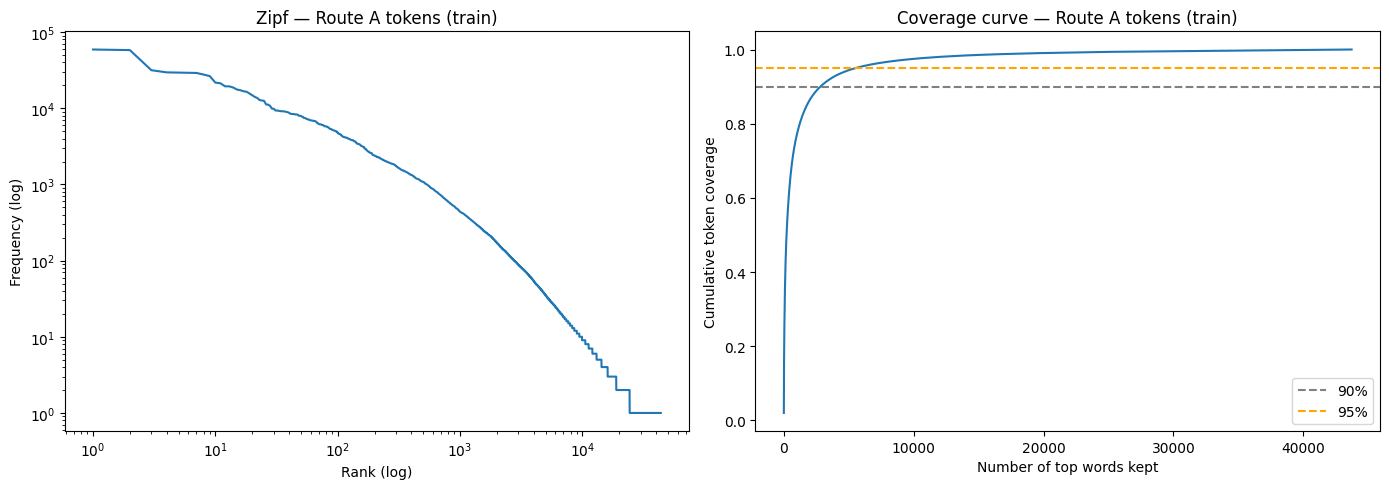

Cut-off values for TfidfVectorizer (from TRAIN vocabulary):
  90% coverage -> top 2,816 words
  95% coverage -> top 5,535 words
  99% coverage -> top 19,287 words

Vocabulary size (Route A, train) : 43,729
Word appears once                : 19,435 (44.4%)


In [140]:
# Vocabulary coverage curve + TfidfVectorizer hand-off values  (TRAIN ONLY)
all_tokens_A = [t for toks in train_df["tokens_A"] for t in toks]
vocab_A      = Counter(all_tokens_A)
freqs_A      = np.array(sorted(vocab_A.values(), reverse=True))
ranks_A      = np.arange(1, len(freqs_A) + 1)
cum_A        = np.cumsum(freqs_A) / freqs_A.sum()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].loglog(ranks_A, freqs_A)
axs[0].set_xlabel("Rank (log)"); axs[0].set_ylabel("Frequency (log)")
axs[0].set_title("Zipf — Route A tokens (train)")

axs[1].plot(ranks_A, cum_A)
axs[1].axhline(0.90, ls="--", color="grey",   label="90%")
axs[1].axhline(0.95, ls="--", color="orange", label="95%")
axs[1].set_xlabel("Number of top words kept")
axs[1].set_ylabel("Cumulative token coverage")
axs[1].set_title("Coverage curve — Route A tokens (train)")
axs[1].legend()
plt.tight_layout(); plt.show()

print("Cut-off values for TfidfVectorizer (from TRAIN vocabulary):")
for target in (0.90, 0.95, 0.99):
    n = int(np.searchsorted(cum_A, target) + 1)
    print(f"  {target*100:.0f}% coverage -> top {n:,} words")

once_A = sum(1 for v in vocab_A.values() if v == 1)
max_95 = int(np.searchsorted(cum_A, 0.95) + 1)
print(f"\nVocabulary size (Route A, train) : {len(vocab_A):,}")
print(f"Word appears once                : {once_A:,} ({once_A/len(vocab_A)*100:.1f}%)")

1. Coverage curves provide strict feature cap which guarantee a huge dimension reduction in the classifier stage. If we keep the top 5535 frequent words (which is only around 10% of the vocabulary), we already able to keep 95% of all token occurence.
2. Zipf laws: the frequency of any word is inversely proportional to its rank in the frequency table. We can see that this rule almost hold true for this tokenized text document. 

In [141]:
# Chi-squared discriminative terms (Route A tokens, TRAIN ONLY)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2 as chi2_test

joined_A   = train_df["tokens_A"].map(" ".join)
_cv_chi    = CountVectorizer(min_df=5)
_X_chi     = _cv_chi.fit_transform(joined_A)
_y_chi     = train_df["sentiment"]
_terms_chi = np.array(_cv_chi.get_feature_names_out())

print("Most discriminative terms per class (chi-squared, Route A tokens, train):")
for lbl, name in [(-1, "Negative"), (0, "Neutral"), (1, "Positive")]:
    scores, _ = chi2_test(_X_chi, (_y_chi == lbl).astype(int))
    top        = _terms_chi[np.argsort(scores)[::-1][:15]]
    print(f"\n  {name}: {', '.join(top)}")

Most discriminative terms per class (chi-squared, Route A tokens, train):

  Negative: not, return, disappoint, waste, receive, love, great, money, break, never, month, send, item, refund, amazon

  Neutral: love, great, th, but, product, may, recommend, very, money, tomorrow, buy, perfect, ok, waste, sunday

  Positive: not, love, great, return, easy, perfect, disappoint, break, good, receive, waste, month, well, send, nice


3. Discrimination features tells whether the top terms per class are actually sentiment bearing, if yes then this tokenisation pipeline is doing its job. We see that some of the negative words are not 

In [142]:
# (1) Directional check: which class does each term actually favour?  (TRAIN ONLY)
# chi2 gives association strength but not direction — this fills that gap.
import pandas as pd

_cv_dir  = CountVectorizer(min_df=5, binary=True)   # binary = "doc contains term?"
_X_dir   = _cv_dir.fit_transform(joined_A)
_terms   = np.array(_cv_dir.get_feature_names_out())
_y       = train_df["sentiment"].to_numpy()

# document-frequency rate of each term within each class
rates = {}
for lbl, name in [(-1, "Negative"), (0, "Neutral"), (1, "Positive")]:
    mask        = (_y == lbl)
    rates[name] = np.asarray(_X_dir[mask].mean(axis=0)).ravel()

rate_df = pd.DataFrame(rates, index=_terms)
rate_df["leans"] = rate_df[["Negative", "Neutral", "Positive"]].idxmax(axis=1)

# inspect the terms that looked suspicious
_probe = ["great", "love", "not", "waste", "disappoint",
          "perfect", "return", "break", "money"]
_probe = [t for t in _probe if t in rate_df.index]   # guard: term may be pruned by min_df in train
print("Directional view of shared / suspicious terms:")
print(rate_df.loc[_probe].round(3).to_string())

Directional view of shared / suspicious terms:
            Negative  Neutral  Positive     leans
great          0.053    0.067     0.184  Positive
love           0.033    0.045     0.151  Positive
not            0.383    0.252     0.140  Negative
waste          0.039    0.003     0.001  Negative
disappoint     0.073    0.026     0.007  Negative
perfect        0.008    0.010     0.051  Positive
return         0.095    0.033     0.009  Negative
break          0.077    0.038     0.017  Negative
money          0.058    0.011     0.013  Negative


The direction of some obvious words looks good

In [143]:
# (2) Does adding bigrams/trigrams produce cleaner discriminative features?  (TRAIN ONLY)
_cv_bi    = CountVectorizer(min_df=5, ngram_range=(2, 3))
_X_bi     = _cv_bi.fit_transform(joined_A)
_terms_bi = np.array(_cv_bi.get_feature_names_out())

print("Top bigram-aware discriminative terms per class:")
for lbl, name in [(-1, "Negative"), (0, "Neutral"), (1, "Positive")]:
    scores, _ = chi2_test(_X_bi, (train_df["sentiment"] == lbl).astype(int))
    top       = _terms_bi[np.argsort(scores)[::-1][:10]]
    print(f"\n  {name}: {', '.join(top)}")

Top bigram-aware discriminative terms per class:

  Negative: waste money, very disappoint, not work, would not, not buy, not recommend, stop work, never receive, not worth, would not recommend

  Neutral: waste money, three star, real madrid, highly recommend, white sox, very disappoint, give three, give three star, super eagle, work great

  Positive: very disappoint, highly recommend, waste money, would not, not work, so far, work great, easy use, great product, not buy


In [144]:
print(pd.crosstab(train_df["Type"], train_df["sentiment"], normalize="index").round(3))

sentiment     -1     0      1
Type                         
Review     0.400  0.20  0.400
Tweet      0.155  0.45  0.395
